# SVI Part I — Pyro vs Bnpyro

This notebook is a companion to the official Pyro tutorial [**SVI Part I: An Introduction to Stochastic Variational Inference in Pyro**](https://pyro.ai/examples/svi_part_i.html).

We take the **exact same probabilistic model** — a Beta-Bernoulli coin-fairness problem — and solve it two ways, side by side:

| | Pyro (SVI) | Bnpyro |
|---|---|---|
| Inference | Stochastic Variational Inference (approximate) | Variable Elimination (exact) |
| Posterior | Approximated by a learned Beta guide after 2000 gradient steps | Exact, computed analytically from the compiled BN |
| Code | `model` + `guide` + optimizer loop | `bn.sample` + `bn.plate` + `bn.compile` + `bn.query` |

The goal is not to say one is better than the other in general — Pyro handles continuous, high-dimensional, and deep generative models that Bnpyro cannot. The goal is to show that for **small discrete/discretizable models**, Bnpyro gives the exact answer with much less ceremony.


## The problem: is this coin fair?

You are given a coin. You suspect it might be slightly biased, but not wildly so — it's a standard quarter, just a bit worn down. You encode this prior belief as:

$$f \sim \mathrm{Beta}(10, 10)$$

where $f \in [0, 1]$ is the probability of heads. This prior is symmetric around $0.5$ and relatively concentrated — it says the coin is probably fair, but allows for some deviation.

You flip the coin 10 times and observe **6 heads, 4 tails**. Each flip is modelled as:

$$x_i \mid f \sim \mathrm{Bernoulli}(f)$$

The **exact posterior** is known analytically thanks to conjugacy:

$$f \mid \mathbf{x} \sim \mathrm{Beta}(10 + 6,\ 10 + 4) = \mathrm{Beta}(16, 14)$$

with posterior mean $\frac{16}{30} \approx 0.533$. We will use this as ground truth to evaluate both approaches.

## Setup

In [1]:
import math
import torch
import torch.distributions.constraints as constraints
import pyro
import pyro.distributions as dist
from pyro.optim import Adam
from pyro.infer import SVI, Trace_ELBO

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import beta as beta_dist

import re

# Bnpyro
import sys
sys.path.insert(0, '..')  # adjust if needed
from Bnpyro import BNppl
from distributions import Beta, Bernoulli

print("pyro version:", pyro.__version__)

C:\Users\louto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pyro version: 1.9.1


In [2]:
# 6 heads (1) and 4 tails (0) — same data as the official Pyro tutorial
n_heads = 6
n_tails = 4
data = [torch.tensor(1.0)] * n_heads + [torch.tensor(0.0)] * n_tails

# Prior hyperparameters
alpha0, beta0 = 10.0, 10.0

# Exact posterior (Beta-Bernoulli conjugacy)
alpha_exact = alpha0 + n_heads   # 16
beta_exact  = beta0  + n_tails   # 14
exact_mean  = alpha_exact / (alpha_exact + beta_exact)  # 16/30 ≈ 0.533
print(f"Exact posterior: Beta({alpha_exact}, {beta_exact}), mean = {exact_mean:.4f}")

Exact posterior: Beta(16.0, 14.0), mean = 0.5333


## Part 1 - Pyro: Stochastic Variational Inference

In Pyro, inference is **variational**: we pick a family of distributions (the *guide*), and optimize its parameters so that it approximates the true posterior as closely as possible. The objective is the **ELBO** (Evidence Lower BOund):

$$\mathrm{ELBO} = \mathbb{E}_{q_\phi(\mathbf{z})} \left[ \log p_\theta(\mathbf{x}, \mathbf{z}) - \log q_\phi(\mathbf{z}) \right]$$

Maximizing the ELBO is equivalent to minimizing $\mathrm{KL}(q_\phi \| p_{\theta}(\cdot \mid \mathbf{x}))$, which moves the guide towards the posterior.

Here the guide is $q(f) = \mathrm{Beta}(\alpha_q, \beta_q)$, which happens to be the conjugate family — so SVI *can* recover the exact posterior, but only after many gradient steps.

In [3]:
def model(data):
    alpha0 = torch.tensor(10.0)
    beta0  = torch.tensor(10.0)
    # latent variable: fairness of the coin
    f = pyro.sample("latent_fairness", dist.Beta(alpha0, beta0))
    # likelihood: each flip is Bernoulli(f)
    for i, x_i in enumerate(data):
        pyro.sample(f"obs_{i}", dist.Bernoulli(f), obs=x_i)

def guide(data):
    # variational parameters — initialized at 15.0
    alpha_q = pyro.param("alpha_q", torch.tensor(15.0), constraint=constraints.positive)
    beta_q  = pyro.param("beta_q",  torch.tensor(15.0), constraint=constraints.positive)
    pyro.sample("latent_fairness", dist.Beta(alpha_q, beta_q))

In [4]:
pyro.clear_param_store()

optimizer = Adam({"lr": 0.0005, "betas": (0.90, 0.999)})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

n_steps = 2000
losses = []
for step in range(n_steps):
    loss = svi.step(data)
    losses.append(loss)
    if step % 500 == 0:
        print(f"step {step:4d}  loss = {loss:.4f}")

alpha_q = pyro.param("alpha_q").item()
beta_q  = pyro.param("beta_q").item()
pyro_mean = alpha_q / (alpha_q + beta_q)
pyro_std  = pyro_mean * math.sqrt(beta_q / (alpha_q * (1.0 + alpha_q + beta_q)))

print(f"\nPyro SVI result:")
print(f"  alpha_q = {alpha_q:.3f}, beta_q = {beta_q:.3f}")
print(f"  Inferred mean  = {pyro_mean:.4f}  (exact = {exact_mean:.4f})")
print(f"  Inferred std   = {pyro_std:.4f}")

step    0  loss = 7.0880
step  500  loss = 7.1313
step 1000  loss = 7.1349
step 1500  loss = 7.0708

Pyro SVI result:
  alpha_q = 16.118, beta_q = 13.936
  Inferred mean  = 0.5363  (exact = 0.5333)
  Inferred std   = 0.0895


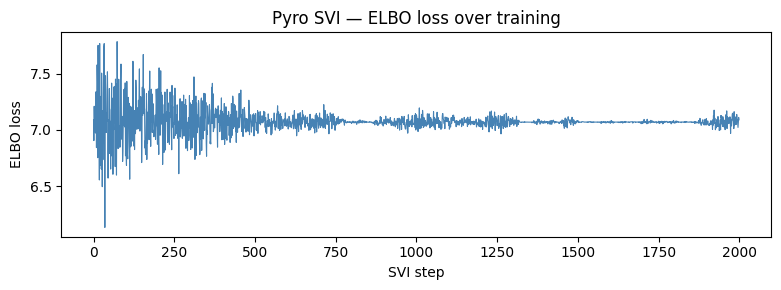

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue', linewidth=0.8)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Pyro SVI — ELBO loss over training")
plt.tight_layout()
plt.show()

## Part 2 - Bnpyro: Exact Inference via Bayesian Networks

In Bnpyro, the same probabilistic program is **compiled** into a Bayesian Network. There is no guide, no optimization loop, and no approximation. The posterior is computed by exact Variable Elimination.

The key construct here is `bn.plate`: it models the $!$-type of the λ!-calculus, corresponding to a *thunk* — a reusable distribution that is instantiated independently each time it is called. Each call to `coin()` creates a new independent Bernoulli node with `f` as parent.

```
f ~ Beta(10, 10)          ← shared parameter node
x_i | f ~ Bernoulli(f)    ← N independent observations, all children of f
```

This is exactly the plate notation from the Pyro tutorial — but here it compiles to a concrete BN.

In [6]:
N = 10  # number of coin flips

bn = BNppl()  # 50 bins for f ∈ [0,1]

# Prior on fairness
f = bn.sample("f", Beta(10.0, 10.0))

# Plate: thunk over Bernoulli(f) — one independent flip per call
coin = bn.plate("flip", lambda fairness: Bernoulli(fairness), parents=[f])
flips = [coin() for _ in range(N)]

bn.compile(n_bins=50)
print(bn)

BN compiled: 11 nodes, 10 arcs  [method=midpoint]
Nodes: ['f', 'flip_1', 'flip_5', 'flip_9', 'flip_2', 'flip_3', 'flip_7', 'flip_8', 'flip_10', 'flip_6', 'flip_4']
Arcs:  [('f', 'flip_1'), ('f', 'flip_7'), ('f', 'flip_4'), ('f', 'flip_10'), ('f', 'flip_3'), ('f', 'flip_9'), ('f', 'flip_6'), ('f', 'flip_2'), ('f', 'flip_5'), ('f', 'flip_8')]


In [7]:
# Observed data: 6 heads (True), 4 tails (False)
# flip_1 … flip_6 are heads, flip_7 … flip_10 are tails
evidence = {}
for i, flip_node in enumerate(flips):
    evidence[flip_node.name] = True if i < n_heads else False

posterior_f = bn.query("f", evidence=evidence)

# Posterior mean from discretized distribution
# bin labels are the midpoints of the discretization intervals
def midpoint(label):
    nums = re.findall(r'[-+]?\d+\.?\d*', str(label))
    return (float(nums[0]) + float(nums[1])) / 2 if len(nums) >= 2 else float(label)

bnpyro_mean = sum(midpoint(k) * v for k, v in posterior_f.items())

print("Bnpyro exact posterior (selected bins):")
items = sorted(posterior_f.items(), key=lambda x: -x[1])[:5]
for label, prob in items:
    print(f"  f ≈ {midpoint(label):.4f} -> p = {prob:.4f}")
print(f"\nBnpyro posterior mean = {bnpyro_mean:.4f}  (exact = {exact_mean:.4f})")

Bnpyro exact posterior (selected bins):
  f ≈ 0.5327 -> p = 0.0568
  f ≈ 0.5458 -> p = 0.0565
  f ≈ 0.5196 -> p = 0.0561
  f ≈ 0.5589 -> p = 0.0552
  f ≈ 0.5065 -> p = 0.0542

Bnpyro posterior mean = 0.5333  (exact = 0.5333)


## Part 3 - Comparison

Let's visualize the three posteriors on the same plot: the true analytical posterior, the Pyro SVI approximation, and the Bnpyro exact discretized posterior.

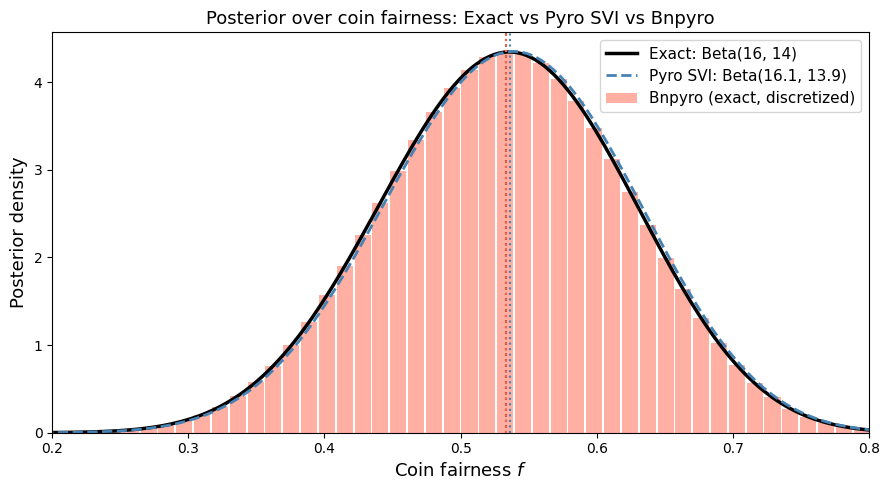


Summary:
  Exact posterior mean  : 0.5333
  Pyro SVI mean         : 0.5363  (error = 0.0030)
  Bnpyro mean           : 0.5333  (error = 0.0000)


In [8]:
f_vals = np.linspace(0, 1, 300)

# --- Exact analytical posterior Beta(16, 14) ---
exact_pdf = beta_dist.pdf(f_vals, alpha_exact, beta_exact)

# --- Pyro SVI posterior Beta(alpha_q, beta_q) ---
pyro_pdf = beta_dist.pdf(f_vals, alpha_q, beta_q)

# --- Bnpyro: bin midpoints and probabilities ---
items_sorted   = sorted(posterior_f.items(), key=lambda kv: midpoint(kv[0]))
bnpyro_labels  = [midpoint(k) for k, v in items_sorted]
bnpyro_probs   = [v           for k, v in items_sorted]
# convert to a density-like value for visual comparison
bin_width = bnpyro_labels[1] - bnpyro_labels[0] if len(bnpyro_labels) > 1 else 0.02
bnpyro_density = [p / bin_width for p in bnpyro_probs]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(f_vals, exact_pdf, color='black', linewidth=2.5, label=f'Exact: Beta({alpha_exact:.0f}, {beta_exact:.0f})')
ax.plot(f_vals, pyro_pdf,  color='steelblue', linewidth=2, linestyle='--',
        label=f'Pyro SVI: Beta({alpha_q:.1f}, {beta_q:.1f})')
ax.bar(bnpyro_labels, bnpyro_density, width=bin_width * 0.9,
       color='tomato', alpha=0.5, label='Bnpyro (exact, discretized)')

ax.axvline(exact_mean,   color='black',     linestyle=':', linewidth=1.5)
ax.axvline(pyro_mean,    color='steelblue', linestyle=':', linewidth=1.5)
ax.axvline(bnpyro_mean,  color='tomato',    linestyle=':', linewidth=1.5)

ax.set_xlabel("Coin fairness $f$", fontsize=13)
ax.set_ylabel("Posterior density", fontsize=13)
ax.set_title("Posterior over coin fairness: Exact vs Pyro SVI vs Bnpyro", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0.2, 0.8)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Exact posterior mean  : {exact_mean:.4f}")
print(f"  Pyro SVI mean         : {pyro_mean:.4f}  (error = {abs(pyro_mean - exact_mean):.4f})")
print(f"  Bnpyro mean           : {bnpyro_mean:.4f}  (error = {abs(bnpyro_mean - exact_mean):.4f})")

## Discussion

### What just happened?

Both approaches solve the same model. The differences are fundamental:

**Pyro** defines a `model` and a `guide`, then runs 2000 gradient steps to tune the guide's parameters $(\alpha_q, \beta_q)$ so that $\mathrm{Beta}(\alpha_q, \beta_q)$ approximates the posterior. In this conjugate case, SVI recovers the exact posterior parameters — but only because we chose the right guide family, and only after enough steps.

**Bnpyro** compiles the program into a Bayesian Network and runs Variable Elimination once. No iteration, no approximation, no guide to choose. The discretization of `f` into `n_bins=50` intervals introduces a small quantization error, but this is controlled and decreases with more bins.

### When does each approach win?

| Scenario | Pyro | Bnpyro |
|---|---|---|
| High-dimensional continuous latent space | ✅ | ❌ (CPT explosion) |
| Deep generative models, VAEs | ✅ | ❌ |
| Small discrete/discretizable models | ⚠️ approximate | ✅ exact |
| No need to design a guide | ❌ requires guide | ✅ |
| Guaranteed exact answer | ❌ | ✅ |
| Higher-order programs (thunks, HOF) | ⚠️ limited | ✅ (λ!-calculus) |

### The λ!-calculus connection

`bn.plate` in Bnpyro corresponds to the `!`-type (*bang type*) of the λ!-calculus (Faggian, Pautasso & Vanoni, POPL 2024). Each call to `coin()` is a `der` (dereliction), instantiating the shared thunk as an independent node. This is the formal justification for why the N flip nodes are all independent given `f`: the BN structure is not hand-coded, it is derived from the type of the program.

## Bonus: effect of `n_bins` on Bnpyro accuracy

Since Bnpyro discretizes the continuous variable `f`, more bins means more accuracy. Here we measure the error on the posterior mean as a function of `n_bins`.

  n_bins=  5  mean=0.53570  error=0.00236
  n_bins= 10  mean=0.53391  error=0.00058
  n_bins= 20  mean=0.53345  error=0.00012
  n_bins= 30  mean=0.53337  error=0.00003
  n_bins= 50  mean=0.53332  error=0.00001
  n_bins=100  mean=0.53330  error=0.00003


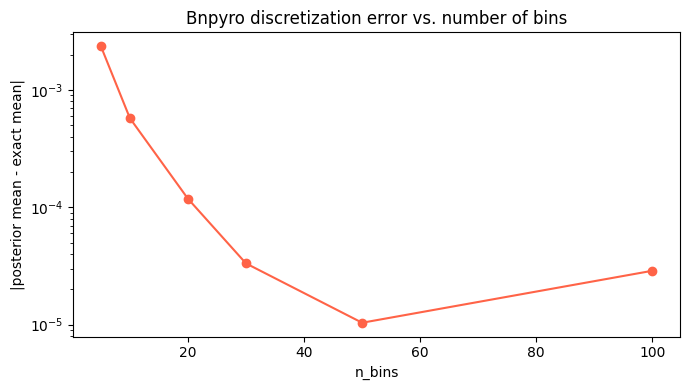

In [9]:
bins_list = [5, 10, 20, 30, 50, 100]
errors = []

for n_bins in bins_list:
    bn_exp = BNppl()
    f_exp  = bn_exp.sample("f", Beta(10.0, 10.0))
    coin_exp = bn_exp.plate("flip", lambda fairness: Bernoulli(fairness), parents=[f_exp])
    flips_exp = [coin_exp() for _ in range(N)]
    bn_exp.compile(n_bins=n_bins)

    ev = {flips_exp[i].name: (True if i < n_heads else False) for i in range(N)}
    post = bn_exp.query("f", evidence=ev)

    mean = sum(midpoint(k) * v for k, v in post.items())
    errors.append(abs(mean - exact_mean))
    print(f"  n_bins={n_bins:3d}  mean={mean:.5f}  error={errors[-1]:.5f}")

plt.figure(figsize=(7, 4))
plt.plot(bins_list, errors, 'o-', color='tomato')
plt.xlabel("n_bins")
plt.ylabel("|posterior mean - exact mean|")
plt.title("Bnpyro discretization error vs. number of bins")
plt.yscale('log')
plt.tight_layout()
plt.show()

## References

- Bingham et al. — *Pyro: Deep Universal Probabilistic Programming*, JMLR 2019
- Pyro tutorial: [SVI Part I](https://pyro.ai/examples/svi_part_i.html)
- Faggian C., Pautasso D., Vanoni G. — *Higher-Order Bayesian Networks, Exactly*, POPL 2024
- Gonzales C., Wuillemin P.-H. — *pyAgrum*, 2020 — https://agrum.gitlab.io/